In [37]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [38]:
team_df = pd.read_csv("team_stats.csv")
player_df = pd.read_csv("player_stats.csv")

team_df = team_df[['name','rating','kd','kd_diff','total_maps']]
team_df = team_df.rename(columns={"name":"team"})

player_df = player_df[['name','teams','rating','kd','kd_diff']]
player_df = player_df.rename(columns={"name":"player"})

In [39]:
team_df["strength"] = (
    0.5 * team_df["rating"] +
    0.3 * team_df["kd"] +
    0.2 * team_df["kd_diff"]
)

team_df.sort_values("strength", ascending=False).head()

,team,rating,kd,kd_diff,total_maps,strength
33,NIP,1.04,1.07,11745,1915,2349.841
5,TYLOO,1.06,1.11,11137,1195,2228.263
37,Astralis,1.04,1.11,10522,1149,2105.253
107,Natus Vincere,1.02,1.07,10431,1760,2087.031
14,ORDER,1.05,1.15,8786,735,1758.070


In [40]:
features = team_df[['rating','kd','kd_diff','total_maps']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [41]:
kmeans = KMeans(n_clusters=3, random_state=42)

team_df["cluster"] = kmeans.fit_predict(scaled_features)

team_df.head()

,team,rating,kd,kd_diff,total_maps,strength,cluster
0,Grayhound,1.07,1.16,7229,553,1446.683,2
1,Recca,1.07,1.08,1816,280,364.059,0
2,Kings,1.07,1.20,1922,122,385.295,0
3,Flash,1.07,1.06,1559,316,312.653,0
4,DarkPassage,1.06,1.11,1177,122,236.263,0


In [42]:
best_players = player_df.sort_values("rating", ascending=False)

best_per_team = best_players.groupby("teams").first().reset_index()

best_per_team.head()

,teams,player,rating,kd,kd_diff
0,"[""Bee's Money Crew"", 'Ghost', 'J Money Crew']",bee,0.96,0.98,-73
1,"[""Ben's Anime Team"", 'Chaos', 'blitz']",wippie,1.11,1.19,359
2,"[""Let's Quit"", 'TYLOO']",qz,0.96,0.97,-63
3,"[""Save's"", ""Save's"", 'DreamEaters', 'Warthox',...",JACKPOT,0.89,0.88,-220
4,"[""Save's"", ""Save's"", 'Sherifi', 'RAVE']",bodyaN,0.96,0.97,-61


In [43]:
top_teams = team_df.sort_values("strength", ascending=False).head(5)

leaderboard = top_teams.merge(
    best_per_team,
    left_on="team",
    right_on="teams",
    how="left"
)

leaderboard[['team','strength','player','rating_y']]

,team,strength,player,rating_y
0,NIP,2349.841,NaN,NaN
1,TYLOO,2228.263,NaN,NaN
2,Astralis,2105.253,NaN,NaN
3,Natus Vincere,2087.031,NaN,NaN
4,ORDER,1758.070,NaN,NaN


In [47]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = team_df["cluster"]
pca_df["team"] = team_df["team"]

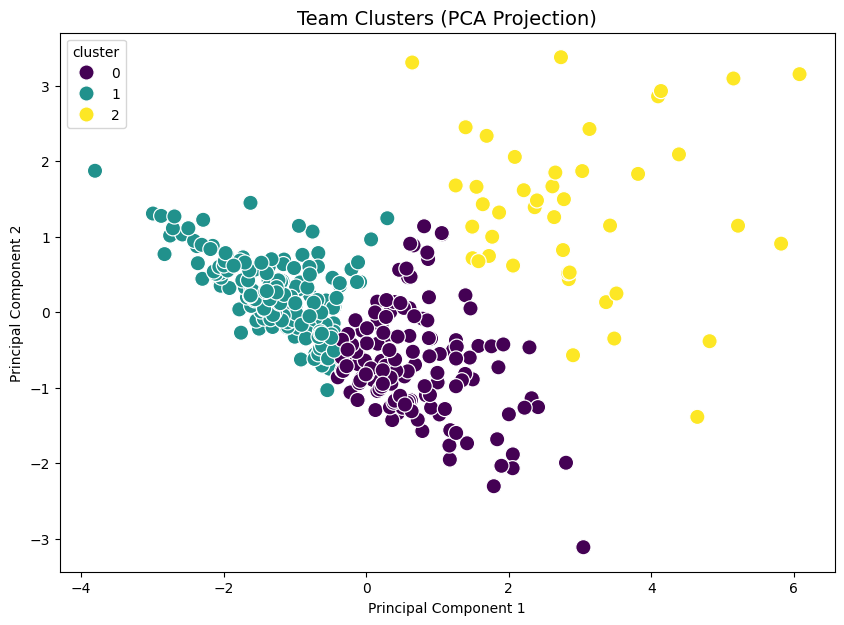

In [45]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=120
)

plt.title("Team Clusters (PCA Projection)", fontsize=14)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()